# Assignment 2

You will be working with the 'taxis' dataset, exploring its features, performing data manipulation tasks, and visualizing insights. The 'taxis' dataset contains information about taxi trips in New York.

Instructions:

1. Download the 'taxis' dataset from Seaborn **sns.load_dataset('taxis')** and load it into a Pandas DataFrame.
2. Answer the following questions by writing Python code using Pandas, NumPy, and visualization libraries.
3. Provide necessary explanations along with your code to demonstrate your understanding.
4. Make use of MatplotLib or Seaborn for data visualization wherever applicable.

#### Q1. Data Preparation:

a. Load the 'taxis' dataset into a Pandas DataFrame.

b. Display the first 5 rows of the dataset.

c. Check for missing values and comment about how would you handle them appropriately.

In [55]:
# Q1. Solution
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# a. Load the taxis dataset
df = sns.load_dataset('taxis')

# b. Display the first 5 rows
df.head()

,pickup,dropoff,passengers,distance,fare,tip,tolls,total,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough
0,2019-03-23 20:21:09,2019-03-23 20:27:24,1,1.60,7.0,2.15,0.0,12.95,yellow,credit card,Lenox Hill West,UN/Turtle Bay South,Manhattan,Manhattan
1,2019-03-04 16:11:55,2019-03-04 16:19:00,1,0.79,5.0,0.00,0.0,9.30,yellow,cash,Upper West Side South,Upper West Side South,Manhattan,Manhattan
2,2019-03-27 17:53:01,2019-03-27 18:00:25,1,1.37,7.5,2.36,0.0,14.16,yellow,credit card,Alphabet City,West Village,Manhattan,Manhattan
3,2019-03-10 01:23:59,2019-03-10 01:49:51,1,7.70,27.0,6.15,0.0,36.95,yellow,credit card,Hudson Sq,Yorkville West,Manhattan,Manhattan
4,2019-03-30 13:27:42,2019-03-30 13:37:14,3,2.16,9.0,1.10,0.0,13.40,yellow,credit card,Midtown East,Yorkville West,Manhattan,Manhattan


I used info() to inspect the column data types first, I noticed the "Non-Null Count" column df.info() was not all the same value. I then ran df.isnull().sum() to identify the missing values clearly. Typically null entries for numerical columns could be filled with a mean or median when appropriate. In this case the columns with missing values have Dtype "str", the most sensible solution would be to just drop the columns as they make up a small percent of every entry (only 25-45 rows with missing entries). If there were columns with an overwhelming amount of missing values, it would be sensible to just drop the entire column alone, but that isn't the case.

In [56]:
# c. Check for missing values and handle them
df.info()

print("=" * 50)

df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 6433 entries, 0 to 6432
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   pickup           6433 non-null   datetime64[us]
 1   dropoff          6433 non-null   datetime64[us]
 2   passengers       6433 non-null   int64         
 3   distance         6433 non-null   float64       
 4   fare             6433 non-null   float64       
 5   tip              6433 non-null   float64       
 6   tolls            6433 non-null   float64       
 7   total            6433 non-null   float64       
 8   color            6433 non-null   str           
 9   payment          6389 non-null   str           
 10  pickup_zone      6407 non-null   str           
 11  dropoff_zone     6388 non-null   str           
 12  pickup_borough   6407 non-null   str           
 13  dropoff_borough  6388 non-null   str           
dtypes: datetime64[us](2), float64(5), int64(1), str(6)


pickup              0
dropoff             0
passengers          0
distance            0
fare                0
tip                 0
tolls               0
total               0
color               0
payment            44
pickup_zone        26
dropoff_zone       45
pickup_borough     26
dropoff_borough    45
dtype: int64

#### Q2. Exploratory Data Analysis:

a. Calculate the average trip duration.

b. Visualize the distribution of trip fares using a histogram.

In [ ]:
# Q2. Solution

# a. Calculate average trip duration
# dt.total_seconds() / 60 to convert seconds to minutes
df['trip_duration'] = (df['dropoff'] - df['pickup']).dt.total_seconds() / 60

average_duration = df['trip_duration'].mean() # average trip duration in minutes

print(f"Average trip duration: {average_duration:.2f} minutes") # minutes rounded 2 decimal places

Average trip duration: 14.35 minutes


I calculated the trip duration by doing dropoff - pickup and converted the timedelta results into total seconds / 60, resulting in minutes. I created the 'trip_duration' column as it might be useful later on. To explore the fare distribution, I created a histogram of the fare column with the appropriate labels and made the bin size 40 as it displayed a nice distribution shape without having too much noise.

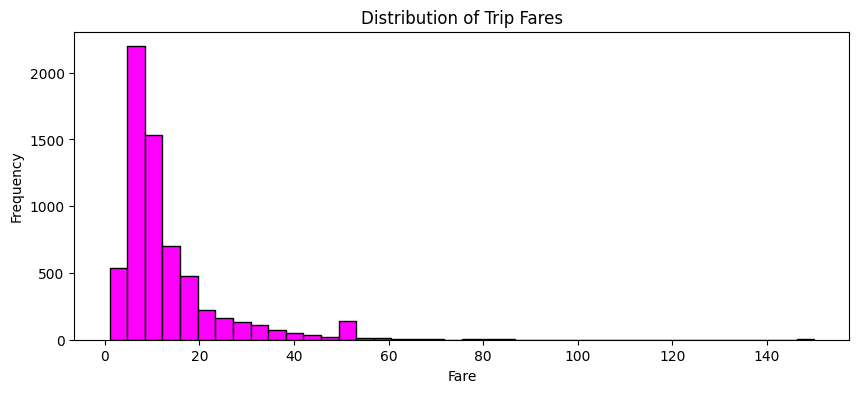

In [65]:
# b. Visualize distribution of trip fares
plt.figure(figsize=(10, 4))

plt.hist(df['fare'], bins=40, color='magenta', edgecolor='black') 

plt.title("Distribution of Trip Fares")
plt.xlabel("Fare")
plt.ylabel("Frequency")

plt.show()

#### Q3. Data Manipulation:

a. Create a new column 'is_tipped' representing if there was any tip for the taxi ride. Display how many cash trips tipped the taxi driver.

b. Display the average tip amounts based on the color of the taxi and number of passengers within a pivot table.

In [59]:
# Q3. Solution
# a. is_tipped column to indicate whether the tip is greater than 0
df['is_tipped'] = df['tip'] > 0

# Display cash trips that were tipped
cash_tipped = df[(df['payment'] == 'cash') & (df['is_tipped'])]
print(f"Number of cash trips that were tipped: {cash_tipped.shape[0]}") # .shape[0] to get no. rows

# b. Average tip amounts based on color of taxi and no. passengers
pivot_table = df.pivot_table(
    values='tip',
    index='color', # rows
    columns='passengers', # columns
    aggfunc='mean', # aggregation
)

print("Average tip amounts based on color of taxi and no. passengers:")
pivot_table.round(2) # round to 2 decimalss

Number of cash trips that were tipped: 0
Average tip amounts based on color of taxi and no. passengers:


passengers,0,1,2,3,4,5,6
color,,,,,,,
green,1.52,0.79,0.74,2.08,0.89,0.58,0.43
yellow,2.41,2.18,2.21,2.22,2.32,2.18,2.15


I created a new boolean column is_tipped using vectorized comparison on the tip column. Then I created a boolean mask that filtered. A pivot table was made to calculate average tip amounts grouped by taxi color and passenger count and rounded it to 2 decimal points for easier viewing on my device.

#### Q4. Advanced Analysis:

a. List the top 5 busiest pickup locations.

b. Plot all the days in a week with number of total rides for each day. Use pickup day column for calculation. 

c. Find which day of the week has the highest average tip amount.

Top 5 busiest pickup locations: 
pickup_zone
Midtown Center                  230
Upper East Side South           211
Penn Station/Madison Sq West    210
Clinton East                    208
Midtown East                    198
Name: count, dtype: int64


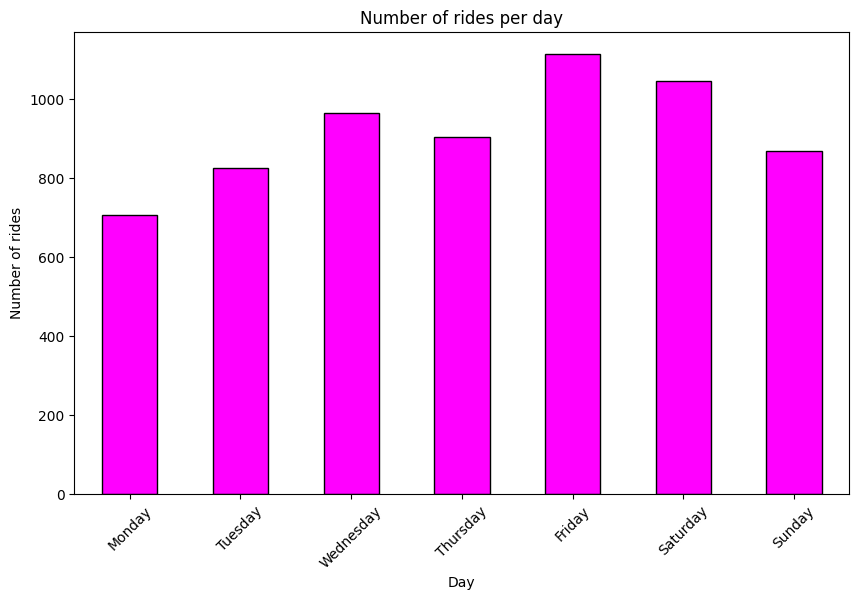

Day with highest average tip amount: Wednesday


In [107]:
# Q4. Solution
# a. Top 5 busiest pickup locations
highest_pickups = df['pickup_zone'].value_counts().head() # .head() default is 5
print(f"Top 5 busiest pickup locations: \n{highest_pickups}")

# b. All days in a week with no. total rides for each day
df['pickup_day'] = df['pickup'].dt.day_name() # convert to day name
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
rides_per_day = df['pickup_day'].value_counts().reindex(day_order) # reindex to sort by day order

plt.figure(figsize=(10, 6))
rides_per_day.plot(kind='bar', color='magenta', edgecolor='black')
plt.title("Number of rides per day")
plt.xlabel("Day")
plt.ylabel("Number of rides")
plt.xticks(rotation=45)

plt.show()

# c. Day of the week with highest average tip amount
avg_tip_by_day = df.groupby('pickup_day')['tip'].mean() # group by day and average each day's tip
avg_tip_by_day = avg_tip_by_day.reindex(day_order) # reorder
highest_day = avg_tip_by_day.idxmax() # returns index of highest value

print(f"Day with highest average tip amount: {highest_day}")

#### Q5. Insights:

a. Explore any additional insights or patterns in the dataset that you find interesting. 

b. Provide visualizations and explanations to support your findings.

Average fare by day of the week:
pickup_day
Monday       13.38
Tuesday      13.33
Wednesday    13.55
Thursday     13.30
Friday       13.12
Saturday     12.49
Sunday       12.59
Name: fare, dtype: float64


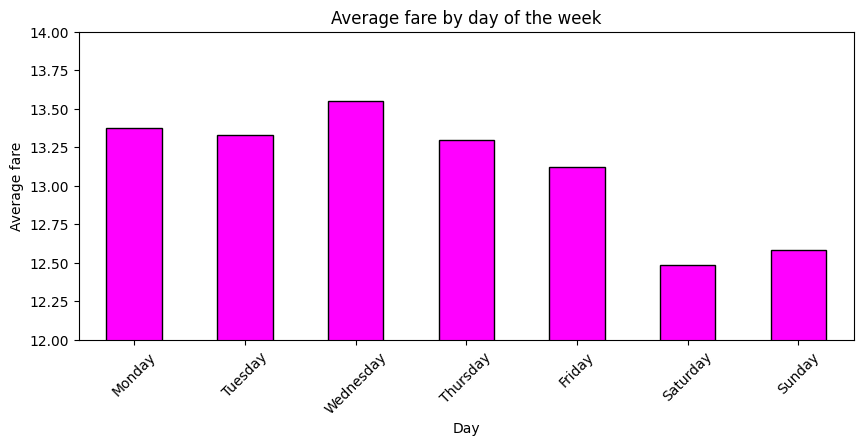

Day with highest average tip amount: Wednesday
Day with highest average fare: Saturday


In [106]:
# Q5. Solution

# a. Average fare by day of the week
# In case Q4 isn't run 
df['pickup_day'] = df['pickup'].dt.day_name() # convert to day name
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

avg_fare_by_day = df.groupby('pickup_day')['fare'].mean().reindex(day_order)
print(f"Average fare by day of the week:\n{avg_fare_by_day.round(2)}")

# b. Visualization
plt.figure(figsize=(10, 4))
avg_fare_by_day.plot(kind='bar', color='magenta', edgecolor='black')

plt.title("Average fare by day of the week")
plt.xlabel("Day")
plt.ylabel("Average fare")
plt.xticks(rotation=45)
plt.ylim(12, 14) # narrow y-axis to make differences more obvious

plt.show()

highest_day = avg_fare_by_day.idxmax() # returns index of highest value
lowest_day = avg_fare_by_day.idxmin() # returns index of lowest value

print(f"Day with highest average tip amount: {highest_day}")
print(f"Day with highest average fare: {lowest_day}")

I wanted to see the average fare for each day of the week, surprisingly every day had very similar average fares. Even more so, I expected the weekends to have a higher average fare because initially I thought people might decide to travel or come home on the weekends more and taxis prices would be priced more accordingly to take advantage of the busier day. Though Wednesday took me by surprise, every day had similar fares so it wasn't anything astounding.

Top 10 dropoff zones by average fare:
dropoff_zone
Bensonhurst East           49.50
JFK Airport                47.05
Saint Albans               46.24
Stapleton                  45.00
West Brighton              44.00
Allerton/Pelham Gardens    41.69
Marble Hill                39.34
Douglaston                 39.00
Woodlawn/Wakefield         38.99
Jamaica Estates            38.61
Name: fare, dtype: float64


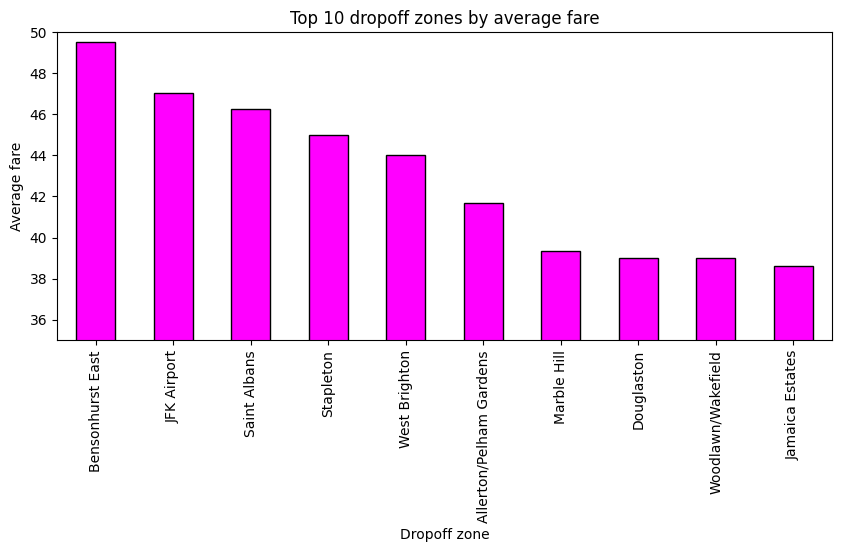

Zone with highest average fare: Bensonhurst East with $49.5


In [105]:
#a. Average fare by dropoff zone
avg_fare_by_dropoff = df.groupby('dropoff_zone')['fare'].mean()

top_dropoff_fares = avg_fare_by_dropoff.sort_values(ascending=False).head(10)
print(f"Top 10 dropoff zones by average fare:\n{top_dropoff_fares.round(2)}")


#b. Visualization
plt.figure(figsize=(10, 4))
top_dropoff_fares.plot(kind='bar', color='magenta', edgecolor='black')

plt.title("Top 10 dropoff zones by average fare")
plt.xlabel("Dropoff zone")
plt.ylabel("Average fare")
plt.ylim(35, 50)

plt.show()

highest_zone = top_dropoff_fares.idxmax()
highest_fare = top_dropoff_fares.max()

print(f"Zone with highest average fare: {highest_zone} with ${highest_fare}")



I wanted to do a little extra and see if dropoff locations made a bigger difference in the average fare amounts. The data was a little more diversed than compared to the average fares for each day of the week. This could've been because many other factors (distance being the biggest ones) and was interesting to me to figure out how one statistic showed a bigger distribution than the other.